## 说明

请按照填空顺序编号分别完成 参数优化，不同基函数的实现

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def load_data(filename):
    """载入数据。"""
    xys = []
    with open(filename, 'r') as f:
        for line in f:
            xys.append(map(float, line.strip().split()))
        xs, ys = zip(*xys)
        return np.asarray(xs), np.asarray(ys)

## 不同的基函数 (basis function)的实现 填空顺序 2

请分别在这里实现“多项式基函数”以及“高斯基函数”

其中以及训练集的x的范围在0-25之间

In [ ]:
def identity_basis(x):
    ret = np.expand_dims(x, axis=1)
    return ret

def multinomial_basis(x, feature_num=10):
    '''多项式基函数'''
    x = np.expand_dims(x, axis=1) # shape(N, 1)，先把x从向量变成二维矩阵形式
    #==========
    power=np.arrange(1,feature_num+1)#记录幂次
    ret=np.power(x,power)#每个元素计算 a ** b（逐元素求幂）
    #==========
    return ret

def gaussian_basis(x, feature_num=10):
    '''高斯基函数，正态分布，三个参数初始化都是启发式的'''
    #==========
    mu=np.linspace(0,25,feature_num)#均值
    s = mu[1] - mu[0] #标准差（不是严格意义上的），启发式写法
    x = np.expand_dims(x, axis=1) # (N, 1)
    ret = np.exp(-0.5 * (x - mu) ** 2 / s ** 2)
    #==========
    return ret

## 返回一个训练好的模型 填空顺序 1 用最小二乘法进行模型优化 
## 填空顺序 3 用梯度下降进行模型优化
> 先完成最小二乘法的优化 (参考书中第二章 2.3中的公式)

> 再完成梯度下降的优化   (参考书中第二章 2.3中的公式)

在main中利用训练集训练好模型的参数，并且返回一个训练好的模型。

计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w

In [10]:
def main(x_train, y_train):
    """
    训练模型，并返回从x到y的映射。
    
    """
    basis_func = identity_basis
    phi0 = np.expand_dims(np.ones_like(x_train), axis=1)#构造全 1 列，作为偏置项（截距）对应的特征列
    phi1 = basis_func(x_train)
    phi = np.concatenate([phi0, phi1], axis=1)
    
    
    #==========
    #todo '''计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w'''
    #==========
    # 方式一：最小二乘法 (填空顺序 1)
    # np.linalg.pinv 是伪逆，比 inv 更稳定
    w = np.linalg.pinv(phi.T @ phi) @ phi.T @ y_train

    
    def f(x):
        phi0 = np.expand_dims(np.ones_like(x), axis=1)
        phi1 = basis_func(x)
        phi = np.concatenate([phi0, phi1], axis=1)
        y = np.dot(phi, w)
        return y

    return f

## 评估结果 
> 没有需要填写的代码，但是建议读懂

(300,)
(200,)
训练集预测值与真实值的标准差：0.4
预测值与真实值的标准差：0.4


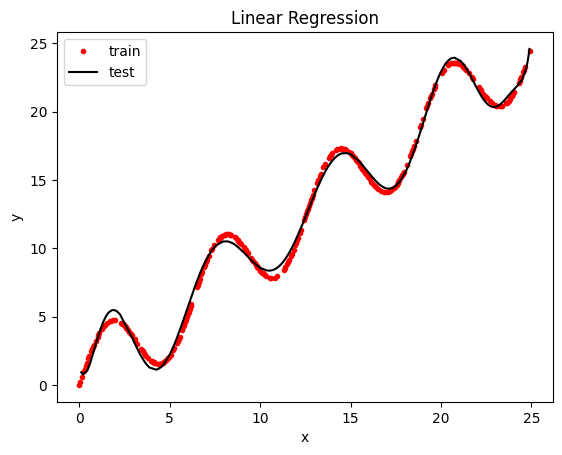

In [86]:
def evaluate(ys, ys_pred):
    """评估模型。"""
    std = np.sqrt(np.mean(np.abs(ys - ys_pred) ** 2))
    return std

# 程序主入口（建议不要改动以下函数的接口）
if __name__ == '__main__':
    train_file = 'train.txt'
    test_file = 'test.txt'
    # 载入数据
    x_train, y_train = load_data(train_file)
    x_test, y_test = load_data(test_file)
    print(x_train.shape)
    print(x_test.shape)

    # 使用线性回归训练模型，返回一个函数f()使得y = f(x)
    f = main(x_train, y_train)

    y_train_pred = f(x_train)
    std = evaluate(y_train, y_train_pred)
    print('训练集预测值与真实值的标准差：{:.1f}'.format(std))
    
    # 计算预测的输出值
    y_test_pred = f(x_test)
    # 使用测试集评估模型
    std = evaluate(y_test, y_test_pred)
    print('预测值与真实值的标准差：{:.1f}'.format(std))

    #显示结果
    plt.plot(x_train, y_train, 'ro', markersize=3)
#     plt.plot(x_test, y_test, 'k')
    plt.plot(x_test, y_test_pred, 'k')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression')
    plt.legend(['train', 'test', 'pred'])
    plt.show()

In [85]:
def main(x_train, y_train):#10次幂+二乘法版本（传统梯度下降会溢出）
    """
    训练模型，并返回从x到y的映射。
    
    """
    basis_func = lambda x: multinomial_basis(x, feature_num=17)
    phi0 = np.expand_dims(np.ones_like(x_train), axis=1)#构造全 1 列，作为偏置项（截距）对应的特征列
    phi1 = basis_func(x_train)
    phi = np.concatenate([phi0, phi1], axis=1)
    
    
    #==========
    #todo '''计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w'''
    #==========
    # 方式一：最小二乘法 (填空顺序 1)
    # np.linalg.pinv 是伪逆，比 inv 更稳定
    w = np.linalg.pinv(phi.T @ phi) @ phi.T @ y_train

    
    def f(x):
        phi0 = np.expand_dims(np.ones_like(x), axis=1)
        phi1 = basis_func(x)
        phi = np.concatenate([phi0, phi1], axis=1)
        y = np.dot(phi, w)
        return y

    return f

In [ ]:
def identity_basis(x):
    ret = np.expand_dims(x, axis=1)
    return ret

def multinomial_basis(x, feature_num=10):
    '''多项式基函数'''
    x = np.expand_dims(x, axis=1) # shape(N, 1)，先把x从向量变成二维矩阵形式
    #==========
    power=np.arange(1,feature_num+1)#记录幂次
    ret=np.power(x,power)#每个元素计算 a ** b（逐元素求幂）
    #==========
    return ret

def gaussian_basis(x, feature_num=10):
    '''高斯基函数，正态分布，三个参数初始化都是启发式的'''
    #==========
    mu=np.linspace(0,25,feature_num)#均值
    s = mu[1] - mu[0] #标准差（不是严格意义上的），启发式写法
    x = np.expand_dims(x, axis=1) # (N, 1)
    ret = np.exp(-0.5 * (x - mu) ** 2 / s ** 2)
    #==========
    return ret

In [ ]:
def main(x_train, y_train):#高斯+梯度版本
    basis_func = lambda x: gaussian_basis(x, feature_num=10)
    phi0 = np.expand_dims(np.ones_like(x_train), axis=1)
    phi1 = basis_func(x_train)
    phi = np.concatenate([phi0, phi1], axis=1)

    # 梯度下降：先用小学习率，并对梯度做均值
    alpha = 0.3
    iters = 80000
    n = phi.shape[0]
    w = np.zeros(phi.shape[1], dtype=np.float64)

    for i in range(iters):
        err = phi @ w - y_train
        gradient = (phi.T @ err) / n
        w = w - alpha * gradient

        # 防止数值爆炸，出现非有限数就停止
        if not np.all(np.isfinite(w)):
            raise ValueError("w 出现 NaN/Inf，请进一步减小学习率 alpha")

    def f(x):
        phi0 = np.expand_dims(np.ones_like(x), axis=1)
        phi1 = basis_func(x)
        phi = np.concatenate([phi0, phi1], axis=1)
        y = np.dot(phi, w)
        return y

    return f